In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import (
    kge,
    kge_alpha,
    kge_beta,
    kge_r,
    mkge,
    mkge_alpha,
    nse,
)
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"cmaes_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
# Parameter names, search bounds, and initial guess (midpoint of bounds)
param_names = [
    "harvest_index",
    "gdd_emergence",
    "gdd_max_rooting",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "gdd_hi_start",
    "max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    "min_rooting_depth",
    "max_rooting_depth",
    #"p_upper_senescence",
    #"p_upper_stomata"
]

bounds = [
    (0.46, 0.6),    # harvest_index
    (5, 60),        # gdd_emergence
    (700, 1000),    # gdd_max_rooting
    (700, 1000),    # gdd_senescence
    (900, 1200),    # gdd_maturity
    (380,  530),    # gdd_flowering
    (90,  170),    # gdd_flowering_length
    (300, 500),     # gdd_hi_start
    (0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    (0.1, 0.4),    # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    #(0.4, 0.8),     # p_upper_senescence
    #(0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")
print(f"Bounds:     {bounds}")

Parameters: ['harvest_index', 'gdd_emergence', 'gdd_max_rooting', 'gdd_senescence', 'gdd_maturity', 'gdd_flowering', 'gdd_flowering_length', 'gdd_hi_start', 'max_canopy_cover', 'min_rooting_depth', 'max_rooting_depth']
x0:         [5.30e-01 3.25e+01 8.50e+02 8.50e+02 1.05e+03 4.55e+02 1.30e+02 4.00e+02
 9.10e-01 2.50e-01 1.50e+00]
Bounds:     [(0.46, 0.6), (5, 60), (700, 1000), (700, 1000), (900, 1200), (380, 530), (90, 170), (300, 500), (0.85, 0.97), (0.1, 0.4), (0.5, 2.5)]


In [6]:
def evaluate_params(param_values):
    """Run one candidate and return all metrics for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(jablje_maize_params)

        for name, val in zip(param_names, param_values):
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es",
            params=crop_params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {
            f"{prefix}_{s}": np.nan
            for prefix in ("biomass", "grain")
            for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_metrics

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain,   "grain_modeled",   "grain"),
        }
    finally:
        dir_queue.put(working_dir)

In [7]:
eval_log = []           # collects every evaluated candidate for post-analysis
eval_log_lock = threading.Lock()
convergence_logs = {}   # objective_name -> [(iteration, fbest), ...]

mean_biomass = observed_biomass["yield"].mean()
mean_grain   = observed_grain["yield"].mean()
print(f"Mean observed biomass: {mean_biomass:.1f}  |  mean observed grain: {mean_grain:.1f}")


def make_objective(scalar_fn):
    """Return a function that evaluates one candidate, logs it, and returns a scalar."""
    def objective(param_values):
        r = evaluate_params(param_values)
        with eval_log_lock:
            eval_log.append({**dict(zip(param_names, param_values)), **r})
        return scalar_fn(r)
    return objective


objectives = {
    "biomass_rmse":   make_objective(lambda r: r["biomass_rmse"]),
    "biomass_mkge":   make_objective(lambda r: -r["biomass_mkge"]),   # negate: CMA-ES minimises
    "grain_rmse":     make_objective(lambda r: r["grain_rmse"]),
    "grain_mkge":     make_objective(lambda r: -r["grain_mkge"]),     # negate: CMA-ES minimises
    "combined_nrmse": make_objective(
        lambda r: r["biomass_rmse"] / mean_biomass + r["grain_rmse"] / mean_grain
    ),
}

Mean observed biomass: 18.3  |  mean observed grain: 9.4


In [10]:
# CMA-ES settings
SIGMA0 = 0.02

default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = max(MAX_WORKERS, default_popsize)

CMAES_OPTIONS = {
    "bounds": [lower.tolist(), upper.tolist()],
    "CMA_stds": (upper - lower).tolist(),  # scale sigma0 per-coordinate to each param's own range
    "popsize": POPSIZE,
    "maxiter": 20,
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 42,
    "verbose": 3,
}

print(f"Cores: {MAX_WORKERS}  |  default popsize: {default_popsize}  |  using popsize: {POPSIZE}")
print(f"Options: {CMAES_OPTIONS}")

Cores: 28  |  default popsize: 11  |  using popsize: 28
Options: {'bounds': [[0.46, 5.0, 700.0, 700.0, 900.0, 380.0, 90.0, 300.0, 0.85, 0.1, 0.5], [0.6, 60.0, 1000.0, 1000.0, 1200.0, 530.0, 170.0, 500.0, 0.97, 0.4, 2.5]], 'CMA_stds': [0.13999999999999996, 55.0, 300.0, 300.0, 300.0, 150.0, 80.0, 200.0, 0.12, 0.30000000000000004, 2.0], 'popsize': 28, 'maxiter': 20, 'tolx': 1e-05, 'tolfun': 1e-05, 'seed': 42, 'verbose': 3}


In [11]:
def parallel_evaluate(objective_fn, solutions):
    """Evaluate a list of candidate solutions in parallel using ThreadPoolExecutor."""
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        return list(executor.map(objective_fn, solutions))

In [12]:
def run_cmaes(objective_name):
    """Run CMA-ES for a given objective and return the CMAEvolutionStrategy object."""
    objective_fn = objectives[objective_name]
    es = cma.CMAEvolutionStrategy(x0, SIGMA0, CMAES_OPTIONS)
    convergence_logs[objective_name] = []

    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(objective_fn, solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        es.disp()
        convergence_logs[objective_name].append((es.result.iterations, es.result.fbest))

    es.result_pretty()
    return es

In [13]:
eval_log.clear()
print("=== Optimising for BIOMASS RMSE ===")
es_biomass = run_cmaes("biomass_rmse")
print(f"\nBest biomass RMSE: {es_biomass.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass.result.xbest):
    print(f"  {name}: {val:.4f}")

=== Optimising for BIOMASS RMSE ===
(14_w,28)-aCMA-ES (mu_w=8.1,w_1=21%) in dimension 11 (seed=42, Wed Sep  2 15:18:09 2026)
Error running AquaCrop: AquaCrop failed with code 3221225786: Error running AquaCrop: AquaCrop failed with code 3221225786: 




KeyboardInterrupt



KeyboardInterrupt: 

In [12]:
eval_log.clear()
print("=== Optimising for BIOMASS mKGE ===")
es_biomass_mkge = run_cmaes("biomass_mkge")
print(f"\nBest biomass mKGE: {-es_biomass_mkge.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_biomass_mkge.result.xbest):
    print(f"  {name}: {val:.4f}")

In [13]:
eval_log.clear()
print("=== Optimising for GRAIN RMSE ===")
es_grain = run_cmaes("grain_rmse")
print(f"\nBest grain RMSE: {es_grain.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain.result.xbest):
    print(f"  {name}: {val:.4f}")

In [51]:
eval_log.clear()
print("=== Optimising for GRAIN mKGE ===")
es_grain_mkge = run_cmaes("grain_mkge")
print(f"\nBest grain mKGE: {-es_grain_mkge.result.fbest:.4f}")
print("Best parameters:")
for name, val in zip(param_names, es_grain_mkge.result.xbest):
    print(f"  {name}: {val:.4f}")

In [15]:
eval_log.clear()
print("=== Optimising for COMBINED normalised RMSE (biomass + grain) ===")
es_combined = run_cmaes("combined_nrmse")
print(f"\nBest combined nRMSE: {es_combined.result.fbest:.6f}")
print("Best parameters:")
for name, val in zip(param_names, es_combined.result.xbest):
    print(f"  {name}: {val:.4f}")

In [52]:
# Re-evaluate each best solution to get the full metric set
cmaes_runs = {
    "biomass_rmse":   es_biomass.result.xbest,
    "biomass_mkge":   es_biomass_mkge.result.xbest,
    "grain_rmse":     es_grain.result.xbest,
    "grain_mkge":     es_grain_mkge.result.xbest,
    "combined_nrmse": es_combined.result.xbest,
}

summary_rows = []
for run_name, x in cmaes_runs.items():
    metrics = evaluate_params(x)
    row = {"optimised_for": run_name, **dict(zip(param_names, x)), **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("optimised_for")
summary_df

,harvest_index,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,gdd_hi_start,max_canopy_cover,min_rooting_depth,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
optimised_for,,,,,,,,,,,,,,,,,,,,,
biomass_rmse,0.530626,28.475002,873.896663,881.428015,1066.509370,470.097648,132.810397,406.955054,0.898950,0.234530,...,0.396175,0.448660,3.013581,-1.156873,-0.190061,-0.140633,-0.042128,0.792949,0.463955,0.585101
biomass_mkge,0.515385,30.335336,842.918113,892.079872,1085.722206,457.978207,137.903011,405.772914,0.917617,0.223133,...,0.458592,0.521565,3.169741,-1.386197,-0.179918,-0.126738,-0.052082,0.774907,0.515580,0.665344
grain_rmse,0.525249,29.324046,864.502610,884.301294,1065.068208,464.021554,132.341837,399.046098,0.910780,0.247114,...,0.406575,0.464434,3.069829,-1.238139,-0.202451,-0.152128,-0.060452,0.786969,0.474694,0.603192
grain_mkge,0.599210,11.348720,701.522747,998.285859,1199.023606,529.768238,120.037751,341.229868,0.943874,0.101491,...,0.769318,0.835302,1.953204,0.093947,0.530091,0.535240,0.538594,0.952693,0.924627,0.970541
combined_nrmse,0.535464,29.874915,854.800232,867.614882,1061.826528,465.134487,130.590023,396.353146,0.905936,0.248969,...,0.385583,0.444409,3.016189,-1.160607,-0.205107,-0.156625,-0.058844,0.794146,0.462639,0.582561


In [53]:
display_cols = [
    "biomass_rmse", "biomass_nse", "biomass_kge", "biomass_mkge",
    "grain_rmse", "grain_nse",   "grain_kge",   "grain_mkge",
]
print("Metric comparison across optimisation targets:")
summary_df[display_cols].round(4)

,biomass_rmse,biomass_nse,biomass_kge,biomass_mkge,grain_rmse,grain_nse,grain_kge,grain_mkge
optimised_for,,,,,,,,
biomass_rmse,5.3014,-0.4907,-0.2740,-0.2499,3.0136,-1.1569,-0.1901,-0.1406
biomass_mkge,5.4385,-0.5688,-0.2406,-0.2144,3.1697,-1.3862,-0.1799,-0.1267
grain_rmse,5.3845,-0.5378,-0.2740,-0.2481,3.0698,-1.2381,-0.2025,-0.1521
grain_mkge,4.6213,-0.1328,0.3246,0.3442,1.9532,0.0939,0.5301,0.5352
combined_nrmse,5.4037,-0.5488,-0.2815,-0.2544,3.0162,-1.1606,-0.2051,-0.1566


In [54]:
# Convergence info from each run
for name, es in [
    ("biomass_rmse",   es_biomass),
    ("biomass_mkge",   es_biomass_mkge),
    ("grain_rmse",     es_grain),
    ("grain_mkge",     es_grain_mkge),
    ("combined_nrmse", es_combined),
]:
    r = es.result
    print(f"{name}: evaluations={r.evaluations}, iterations={r.iterations}, stop={es.stop()}")

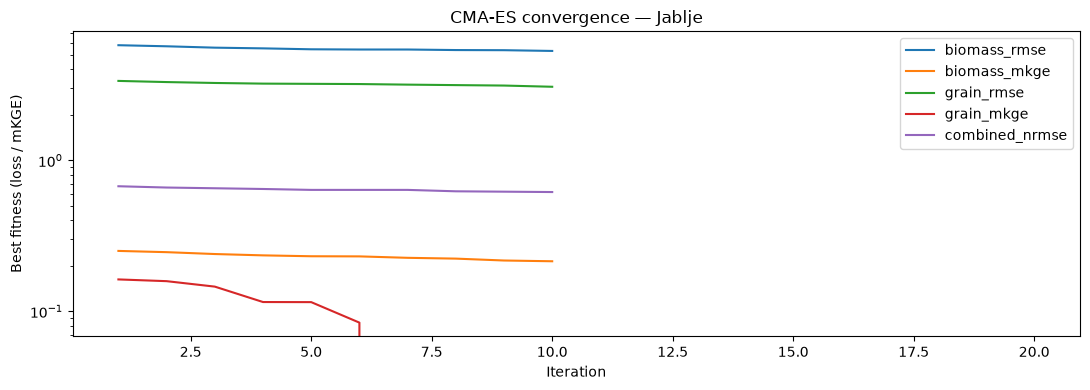

In [55]:
import matplotlib.pyplot as plt

# Objectives whose fitness is already a loss (lower = better) — no sign flip needed
loss_objectives = {"biomass_rmse", "grain_rmse", "combined_nrmse"}

fig, ax = plt.subplots(figsize=(11, 4))

for obj_name, log in convergence_logs.items():
    iters, fbest = zip(*log)
    values = [f for f in fbest]
    ax.plot(iters, values, label=obj_name)

ax.semilogy()
ax.set_xlabel("Iteration")
ax.set_ylabel("Best fitness (loss / mKGE)")
ax.set_title("CMA-ES convergence — Jablje")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# All evaluated candidates from the last CMA-ES run (combined)
all_evals_df = pd.DataFrame(eval_log)
print(f"Total evaluations stored from last run: {len(all_evals_df)}")
all_evals_df.sort_values("grain_mkge")

,harvest_index,gdd_emergence,gdd_max_rooting,gdd_senescence,gdd_maturity,gdd_flowering,gdd_flowering_length,gdd_hi_start,max_canopy_cover,min_rooting_depth,...,biomass_kge_alpha,biomass_mkge_alpha,grain_rmse,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
521,0.574860,5.228788,741.161258,971.008022,1120.306044,520.912591,107.338640,341.746921,0.957355,0.109877,...,1.347374,1.815434,3.819645,-2.465013,0.220167,-0.210455,0.448687,0.723603,1.477282,2.041565
12,0.533749,32.518188,858.820747,828.439558,1042.282157,453.360711,131.209458,401.130023,0.913907,0.253213,...,0.374686,0.465301,3.492430,-1.896772,-0.266704,-0.201745,-0.101657,0.723089,0.439455,0.607746
24,0.532303,33.495283,859.061833,847.350130,1037.211843,451.944670,131.281358,404.463988,0.918010,0.251055,...,0.383955,0.470623,3.431917,-1.797257,-0.259393,-0.196804,-0.100521,0.732609,0.449160,0.613096
7,0.530855,36.451279,858.257206,848.989534,1046.740317,453.955156,128.795818,406.772926,0.907488,0.249270,...,0.411497,0.511092,3.526343,-1.953302,-0.261167,-0.196715,-0.112186,0.722420,0.474135,0.656315
26,0.521791,32.693836,832.832732,841.693703,1054.227840,454.350335,129.039642,398.224040,0.913054,0.256362,...,0.418667,0.516511,3.585424,-2.053092,-0.261436,-0.194603,-0.109319,0.713594,0.472171,0.661680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,0.560354,21.764850,730.176882,998.324871,1095.195437,525.699535,129.551518,337.747502,0.959830,0.100224,...,0.726997,0.876197,2.604444,-0.610976,0.460555,0.494812,0.535143,0.802462,0.810561,1.010093
559,0.570658,16.827325,703.724188,966.055239,1199.962717,525.933856,116.208115,308.690937,0.949811,0.100930,...,0.775056,0.904187,2.375410,-0.340096,0.507706,0.521116,0.550684,0.840366,0.877586,1.044290
500,0.586706,12.964321,706.267680,960.074836,1173.699500,528.012513,119.522545,379.394852,0.961520,0.102786,...,0.748187,0.831956,2.035669,0.015824,0.516725,0.529742,0.538852,0.914038,0.883776,0.966891
558,0.596646,24.812457,702.740873,983.422709,1199.322189,518.492816,98.190518,300.537527,0.951213,0.102153,...,0.785726,0.945760,2.294804,-0.250691,0.526891,0.530346,0.557850,0.856092,0.912675,1.066094


In [57]:
list(zip(param_names, es_grain_mkge.result.xbest))

[('harvest_index', np.float64(0.5992095034568057)),
 ('gdd_emergence', np.float64(11.348719685250787)),
 ('gdd_max_rooting', np.float64(701.5227474221)),
 ('gdd_senescence', np.float64(998.2858593312819)),
 ('gdd_maturity', np.float64(1199.023606298787)),
 ('gdd_flowering', np.float64(529.7682382765496)),
 ('gdd_flowering_length', np.float64(120.03775054050071)),
 ('gdd_hi_start', np.float64(341.2298682972759)),
 ('max_canopy_cover', np.float64(0.9438742562358942)),
 ('min_rooting_depth', np.float64(0.10149125750206135)),
 ('max_rooting_depth', np.float64(0.5481551348652725))]

In [58]:
bounds

[(0.46, 0.6),
 (5, 60),
 (700, 1000),
 (700, 1000),
 (900, 1200),
 (380, 530),
 (90, 170),
 (300, 500),
 (0.85, 0.97),
 (0.1, 0.4),
 (0.5, 2.5)]

In [40]:
output_path = config.RESULTS_DIR / "cmaes_jablje_summary2.pkl"
summary_df.reset_index().to_pickle(output_path)
print(f"Saved summary ({len(summary_df)} rows) to {output_path}")

In [59]:
def rerun_best(param_values, label):
    """Re-run a full simulation with given params and return seasonal results."""
    params = copy.deepcopy(jablje_maize_params)
    for name, val in zip(param_names, param_values):
        params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    best_dir = config.MODEL_RUNNING_DIR / f"cmaes_jablje_best_{label}"
    best_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=simulation_periods,
        crop=Crop(name=f"{LOCATION} maize ({label})", description=label, params=params),
        soil=soil,
        management=jablje_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        ground_water=jablje_groundwater,
        working_dir=best_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    return sim.run()["season"]

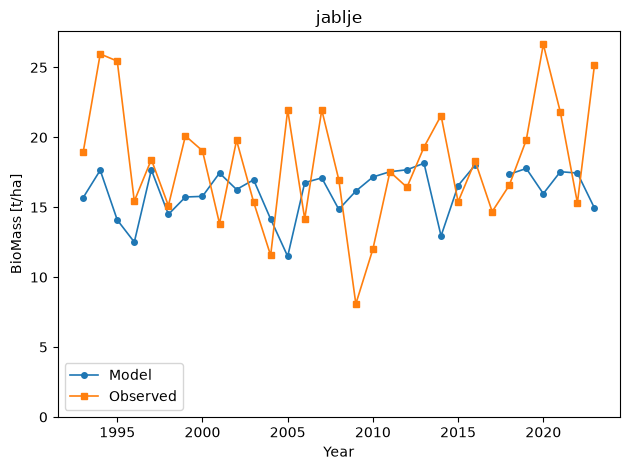

In [60]:
seasonal_biomass_opt = rerun_best(es_biomass.result.xbest, "biomass_opt")
print("=== Best solution optimised for biomass RMSE ===")
plot_yield_timeseries_comparison(seasonal_biomass_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

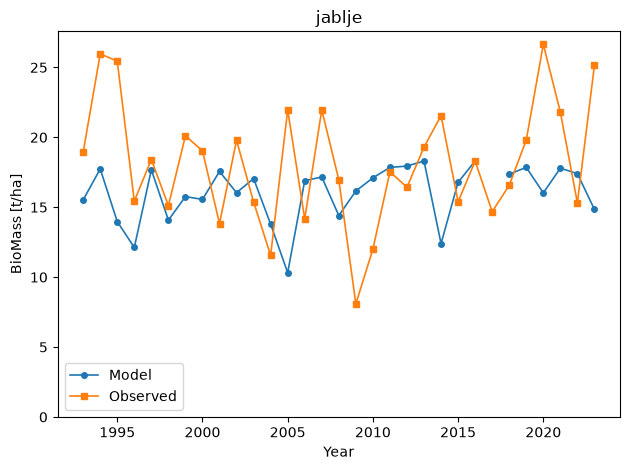

In [61]:
seasonal_biomass_mkge_opt = rerun_best(es_biomass_mkge.result.xbest, "biomass_mkge_opt")
print("=== Best solution optimised for biomass mKGE ===")
plot_yield_timeseries_comparison(seasonal_biomass_mkge_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

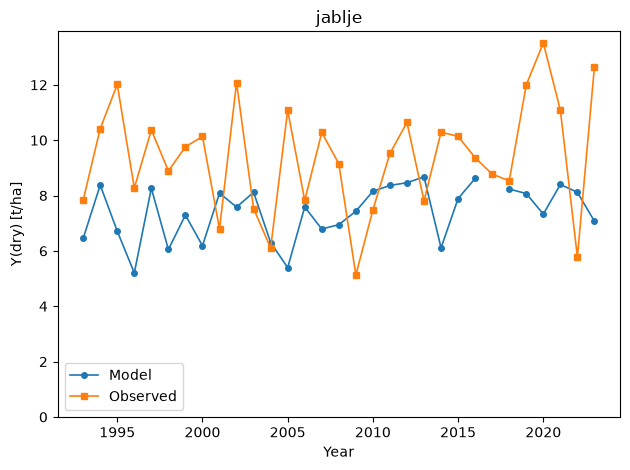

In [62]:
seasonal_grain_opt = rerun_best(es_grain.result.xbest, "grain_opt")
print("=== Best solution optimised for grain RMSE ===")
plot_yield_timeseries_comparison(seasonal_grain_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

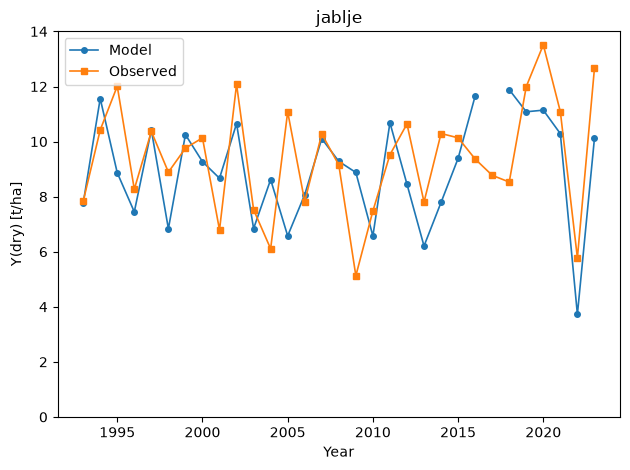

In [63]:
seasonal_grain_mkge_opt = rerun_best(es_grain_mkge.result.xbest, "grain_mkge_opt")
print("=== Best solution optimised for grain mkge ===")
plot_yield_timeseries_comparison(seasonal_grain_mkge_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

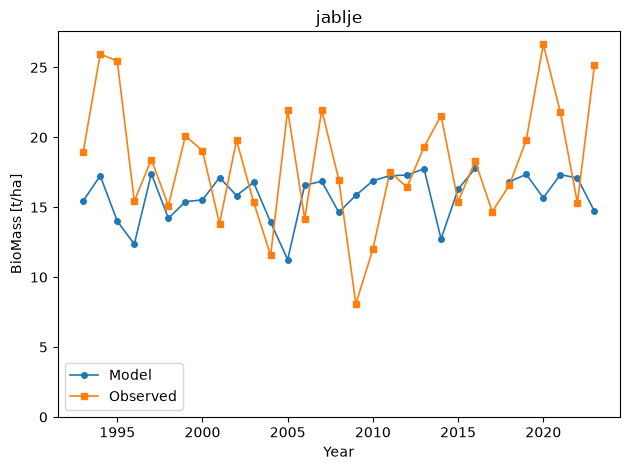

In [46]:
seasonal_combined_opt = rerun_best(es_combined.result.xbest, "combined_opt")
print("=== Best solution optimised for combined nRMSE ===")
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

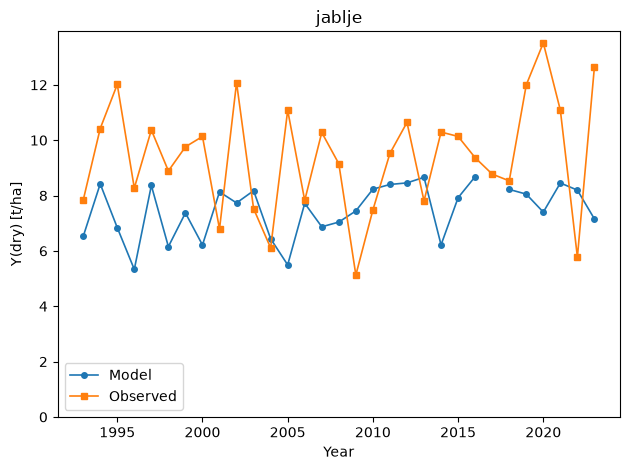

In [47]:
plot_yield_timeseries_comparison(seasonal_combined_opt, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)